Importing Libraries 

In [26]:
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


Reading and Cleaning Data

In [27]:
data = pd.read_csv("X:\\VScode\\Artificial_intelligence_n_Machine_learning\\Projects\\CreditWise_Loan_System\\loan_approval_data.csv")
data = pd.DataFrame(data)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [29]:
categorical_col= data.select_dtypes(include=["object"]).columns
numerical_cols = data.select_dtypes(include=["number"]).columns

In [30]:
num_imp = SimpleImputer(strategy="mean")
data[numerical_cols] = num_imp.fit_transform(data[numerical_cols])

In [31]:
cat_imp = SimpleImputer(strategy="most_frequent")
data[categorical_col] = cat_imp.fit_transform(data[categorical_col])

In [32]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [33]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

EDA - Exploratory Data Analysis

Text(0.5, 1.0, 'Loan Approved Yes or No')

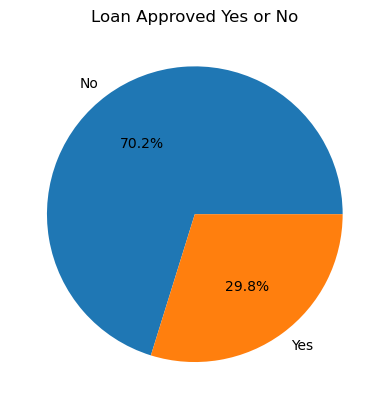

In [34]:
count = data["Loan_Approved"].value_counts()
plt.pie(count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Loan Approved Yes or No")

Analyze Income

<Axes: xlabel='Applicant_Income', ylabel='Count'>

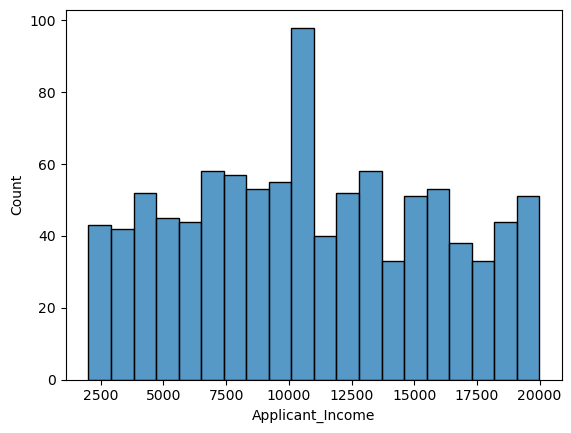

In [35]:
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

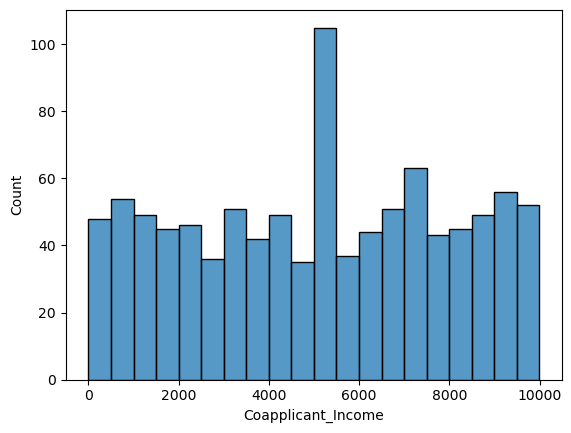

In [36]:
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins = 20
)

outliers

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

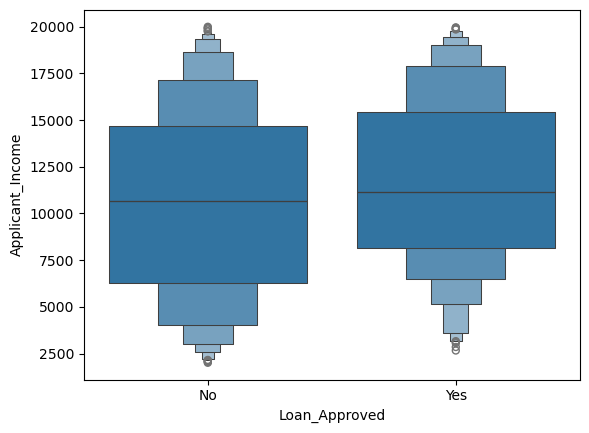

In [37]:
sns.boxenplot(
    data=data,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

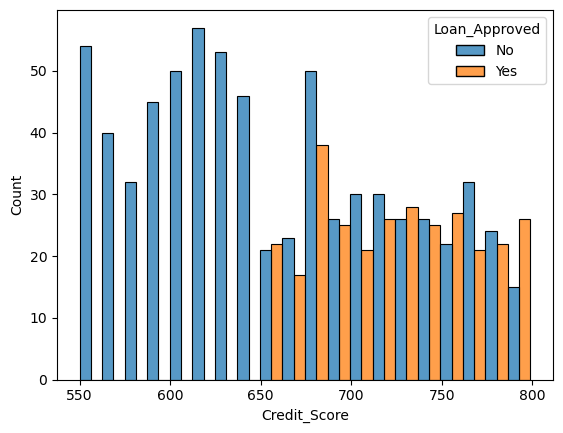

In [38]:
sns.histplot(
    data = data,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple="dodge"
)

Removing Useless data who will not affect model performance

In [39]:
data = data.drop("Applicant_ID",axis=1)
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [40]:
# LabelEncoding - ordinal data - Ordered

Le = LabelEncoder()
data["Education_Level"] = Le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = Le.fit_transform(data["Loan_Approved"])

In [41]:
# OneHotEncoding - nominal data - no Order
cols = ["Employment_Status","Loan_Purpose","Property_Area","Education_Level","Marital_Status","Gender","Employer_Category","Loan_Approved"]
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore",
)
encoded = ohe.fit_transform(data[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols),index=data.index)
data = pd.concat([data.drop(columns=cols), encoded_df], axis=1)

In [42]:
data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Marital_Status_Single,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Approved_1
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
